In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv("heart_failure.csv")

print("First 5 rows:")
display(df.head())

First 5 rows:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset information:")
df.info()


Number of rows: 299
Number of columns: 13

Data types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Dataset information:
<class 'pandas.core.f

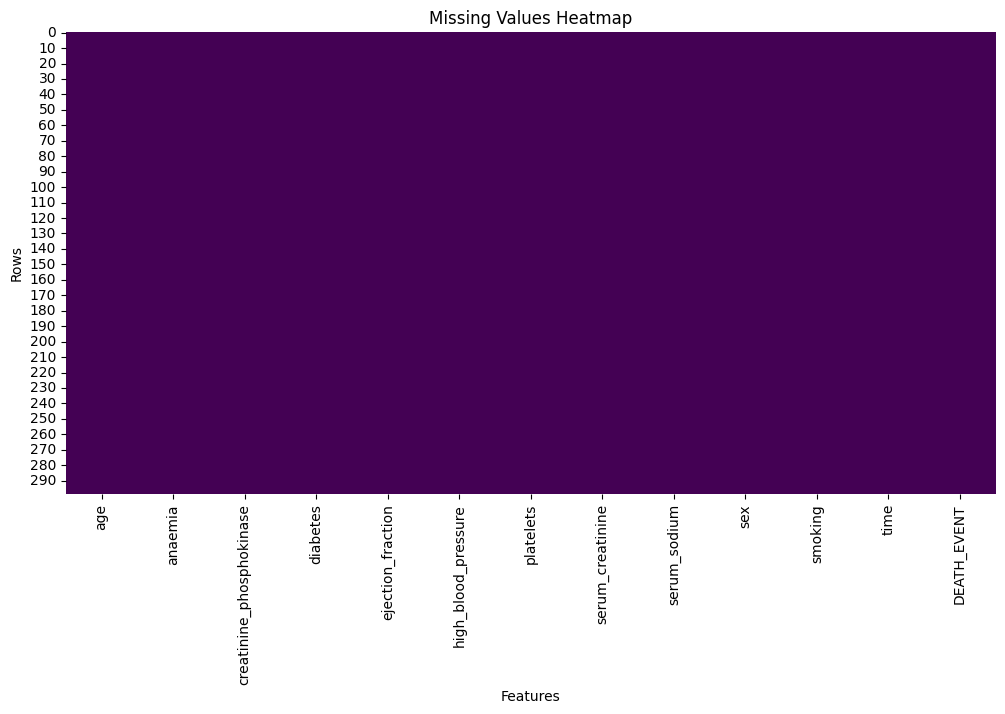

In [4]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Rows")
plt.show()

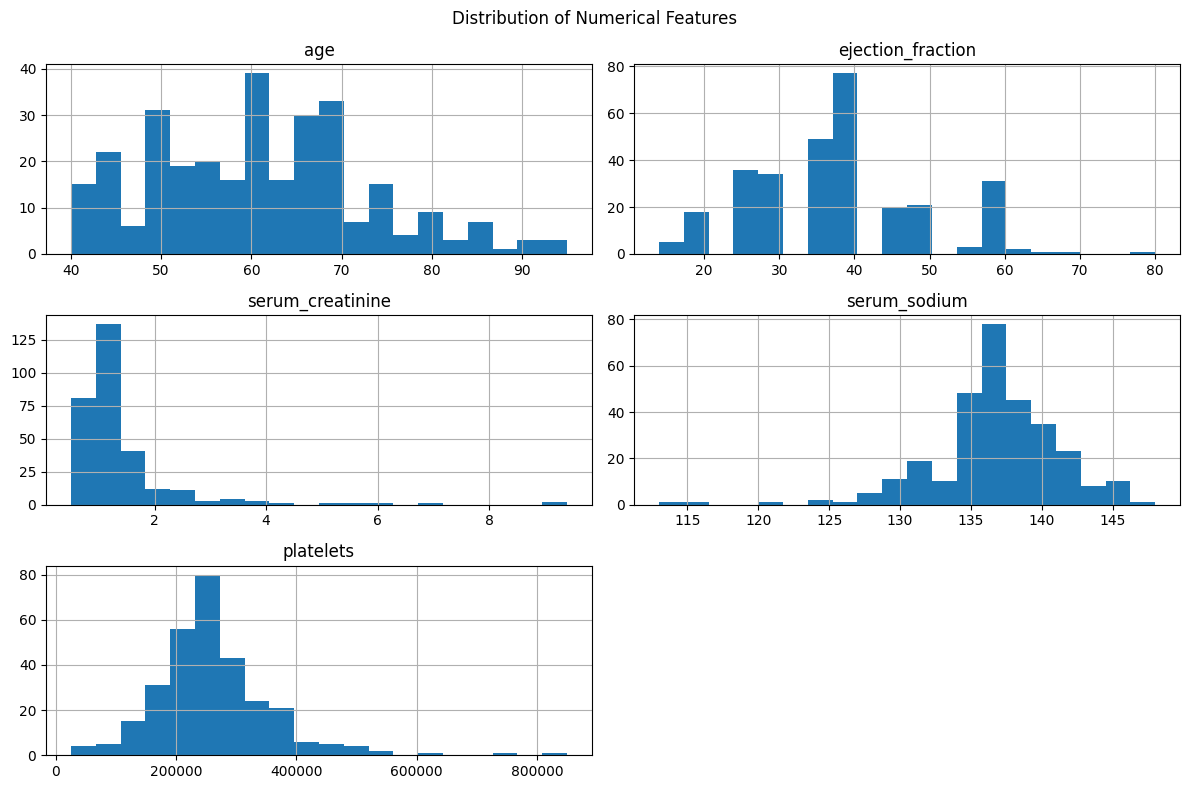

In [5]:
numerical_features = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "serum_sodium",
    "platelets"
]

df[numerical_features].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

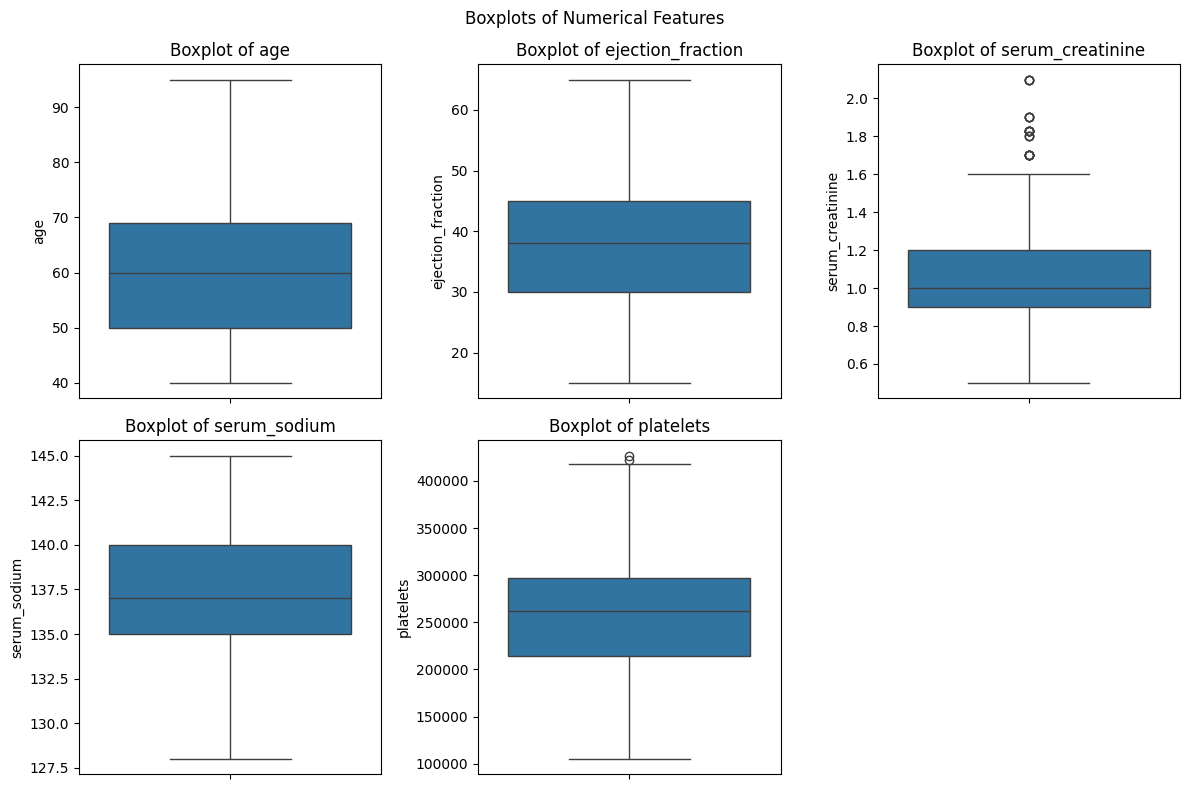

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, feature in zip(axes.flat, numerical_features):

    sns.boxplot(
        y=df[feature],
        ax=ax
    )

    ax.set_title(f"Boxplot of {feature}")
    ax.set_ylabel(feature)

axes.flat[-1].set_visible(False)

plt.suptitle("Boxplots of Numerical Features")
plt.tight_layout()
plt.show()

In [7]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns

categorical_columns = df.select_dtypes(
    exclude=np.number
).columns

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [8]:
def remove_outliers(data, columns):
    cleaned_data = data.copy()

    for column in columns:
        Q1 = cleaned_data[column].quantile(0.25)
        Q3 = cleaned_data[column].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        cleaned_data = cleaned_data[
            (cleaned_data[column] >= lower_bound) &
            (cleaned_data[column] <= upper_bound)
        ]

    return cleaned_data


print("Rows before removing outliers:", len(df))

df = remove_outliers(df, numerical_features)

print("Rows after removing outliers:", len(df))

Rows before removing outliers: 299
Rows after removing outliers: 244


In [9]:
print("Negative age values:", (df["age"] < 0).sum())

df = df[df["age"] >= 0]

print("\nInvalid ejection fraction values:",
      (df["ejection_fraction"] <= 0).sum())

print("Invalid serum creatinine values:",
      (df["serum_creatinine"] <= 0).sum())

print("Invalid serum sodium values:",
      (df["serum_sodium"] <= 0).sum())

df = df[df["ejection_fraction"] > 0]
df = df[df["serum_creatinine"] > 0]
df = df[df["serum_sodium"] > 0]

print("\nDataset shape after correcting inconsistencies:")
print(df.shape)

Negative age values: 0

Invalid ejection fraction values: 0
Invalid serum creatinine values: 0
Invalid serum sodium values: 0

Dataset shape after correcting inconsistencies:
(244, 13)


In [10]:
def create_age_group(age):
    if age < 40:
        return "<40"
    elif age <= 60:
        return "40-60"
    else:
        return ">60"


df["age_group"] = df["age"].apply(create_age_group)

ef_min = df["ejection_fraction"].min()
ef_max = df["ejection_fraction"].max()

creatinine_min = df["serum_creatinine"].min()
creatinine_max = df["serum_creatinine"].max()

ef_normalized = (
    (df["ejection_fraction"] - ef_min) /
    (ef_max - ef_min)
)

creatinine_normalized = (
    (df["serum_creatinine"] - creatinine_min) /
    (creatinine_max - creatinine_min)
)

df["risk_score"] = (
    (1 - ef_normalized) * 0.5 +
    creatinine_normalized * 0.5
)

print("New features created:")
display(df[["age", "age_group",
            "ejection_fraction",
            "serum_creatinine",
            "risk_score"]].head())

New features created:


,age,age_group,ejection_fraction,serum_creatinine,risk_score
0,75.0,>60,20,1.9,0.8875
1,55.0,40-60,38,1.1,0.4575
2,65.0,>60,20,1.3,0.7000
3,50.0,40-60,20,1.9,0.8875
5,90.0,>60,40,2.1,0.7500


In [11]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print("Categorical columns:")
print(list(categorical_columns))

df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print("\nDataset after encoding:")
display(df_encoded.head())

Categorical columns:
['age_group']

Dataset after encoding:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_>60
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1,0.8875,True
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1,0.4575,False
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1,0.7000,True
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1,0.8875,False
5,90.0,1,47,0,40,1,204000.00,2.1,132,1,1,8,1,0.7500,True


In [12]:
scale_columns = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "serum_sodium",
    "platelets",
    "risk_score"
]

scaler = MinMaxScaler()

df_encoded[scale_columns] = scaler.fit_transform(
    df_encoded[scale_columns]
)

print("Normalized numerical features:")
display(df_encoded[scale_columns].head())

Normalized numerical features:


,age,ejection_fraction,serum_creatinine,serum_sodium,platelets,risk_score
0,0.636364,0.10,0.875,0.117647,0.496894,0.984127
1,0.272727,0.46,0.375,0.470588,0.491795,0.438095
2,0.454545,0.10,0.500,0.058824,0.177019,0.746032
3,0.181818,0.10,0.875,0.529412,0.326087,0.984127
5,0.909091,0.50,1.000,0.235294,0.307453,0.809524


In [13]:
original_df = pd.read_csv("heart_failure.csv")

print("Summary statistics BEFORE cleaning:")

before_stats = original_df[numerical_features].agg(
    ["mean", "median", "std"]
)

display(before_stats)

print("\nSummary statistics AFTER cleaning:")

after_stats = df[numerical_features].agg(
    ["mean", "median", "std"]
)

display(after_stats)

Summary statistics BEFORE cleaning:


,age,ejection_fraction,serum_creatinine,serum_sodium,platelets
mean,60.833893,38.083612,1.39388,136.625418,263358.029264
median,60.000000,38.000000,1.10000,137.000000,262000.000000
std,11.894809,11.834841,1.03451,4.412477,97804.236869



Summary statistics AFTER cleaning:


,age,ejection_fraction,serum_creatinine,serum_sodium,platelets
mean,60.362025,37.909836,1.120328,137.213115,256294.576475
median,60.000000,38.000000,1.000000,137.000000,262500.000000
std,11.892853,11.358363,0.325943,3.476504,67732.769517


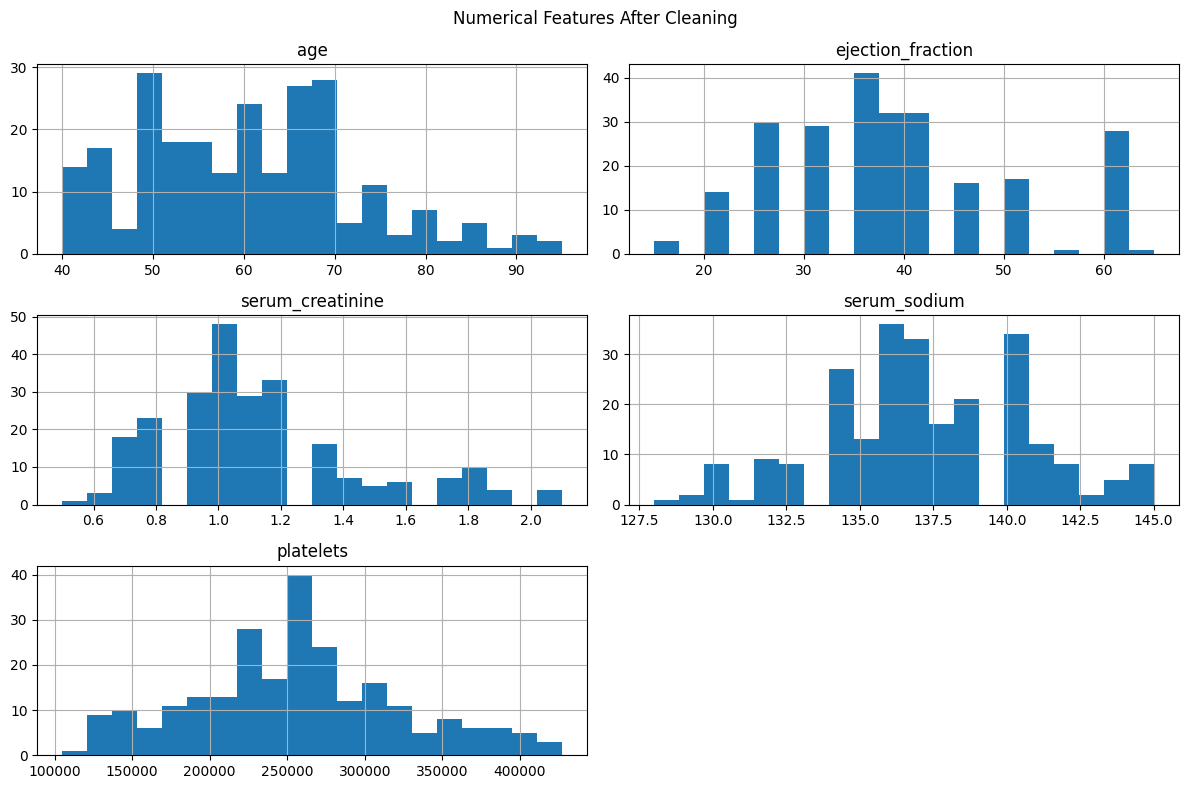

In [14]:
df[numerical_features].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Numerical Features After Cleaning")
plt.tight_layout()
plt.show()

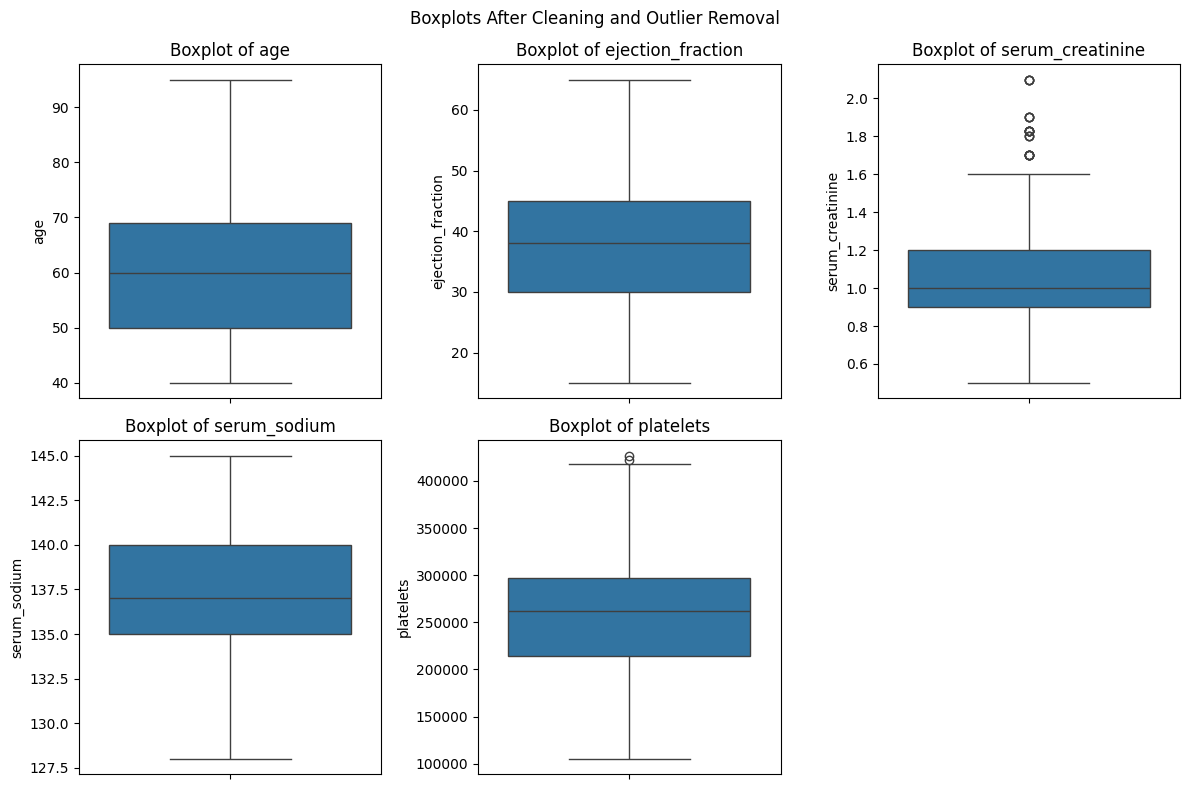

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, feature in zip(axes.flat, numerical_features):

    sns.boxplot(
        y=df[feature],
        ax=ax
    )

    ax.set_title(f"Boxplot of {feature}")
    ax.set_ylabel(feature)

axes.flat[-1].set_visible(False)

plt.suptitle("Boxplots After Cleaning and Outlier Removal")
plt.tight_layout()
plt.show()

In [16]:
print("Missing values before final dataset:")
print(df_encoded.isnull().sum())

total_missing = df_encoded.isnull().sum().sum()

print("\nTotal missing values:", total_missing)

if total_missing == 0:
    print("No missing values remain. Dataset cleaning is complete.")
else:
    print("Some missing values remain and require further investigation.")

Missing values before final dataset:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
risk_score                  0
age_group_>60               0
dtype: int64

Total missing values: 0
No missing values remain. Dataset cleaning is complete.


In [17]:
print("Final cleaned dataset shape:")
print(df_encoded.shape)

print("\nFinal cleaned dataset:")
display(df_encoded.head())

Final cleaned dataset shape:
(244, 15)

Final cleaned dataset:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_>60
0,0.636364,0,582,0,0.10,1,0.496894,0.875,0.117647,1,0,4,1,0.984127,True
1,0.272727,0,7861,0,0.46,0,0.491795,0.375,0.470588,1,0,6,1,0.438095,False
2,0.454545,0,146,0,0.10,0,0.177019,0.500,0.058824,1,1,7,1,0.746032,True
3,0.181818,1,111,0,0.10,0,0.326087,0.875,0.529412,1,0,7,1,0.984127,False
5,0.909091,1,47,0,0.50,1,0.307453,1.000,0.235294,1,1,8,1,0.809524,True
